Theoretical Qmax = F*c_max/(3600*rho) = 609.7 mAh/g (check vs. 609.7)
Fitted parameters (least-squares, bounded to hint ranges):
  V0      = 3.8236 V
  Om2/F   = -0.0000 V
  Om3/F   = 2.0000 V
  Om4/F   = -2.5153 V
  Om5/F   = 10.0000 V
  Om6/F   = 11.0000 V
  Om7/F   = -4.0000 V
  RMSE    = 22.12 mV
Problem 2 done. Max sim capacity: 158.63888363512956


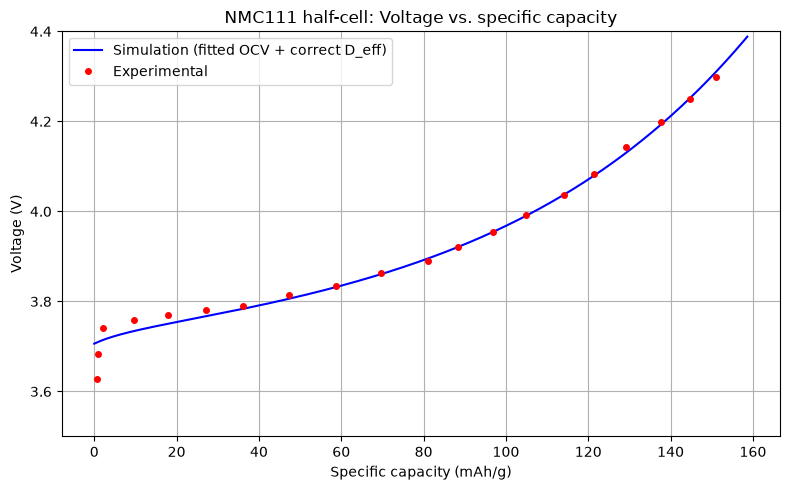

In [ ]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ----------------------------------------------------------------------
# Physical constants
F = 96485
R_gas = 8.314
T = 298
Vth = R_gas * T / F

# ----------------------------------------------------------------------
# NMC parameters (given)
R_p = 10e-6              # m
D = 7e-15                # m^2/s (guest diffusivity at infinite dilution)
c_max = 48000             # mol/m^3   (Nmax = 48 kmol/m^3)
i_app = -10.0             # A/m^2  (= -1 mA/cm^2, Li+ leaving the cathode)
rho = 2110.0               # kg/m^3 = 2.11 g/cm^3
theta0 = 0.99               # initial fractional occupancy

# ----------------------------------------------------------------------
# Experimental data (Table 2): specific capacity (mAh/g) vs voltage (V)
cap_exp = np.array([
    0.7200, 0.9900, 2.1000, 9.6900, 17.8500, 27.1350, 36.1500,
    47.4000, 58.6500, 69.6150, 81.1500, 88.4700, 96.9000,
    104.7750, 114.0450, 121.3650, 129.2250, 137.6550,
    144.6750, 151.1400
])
V_exp = np.array([
    3.6278, 3.6829, 3.7407, 3.7591, 3.7696, 3.7801, 3.7906,
    3.8143, 3.8353, 3.8642, 3.8904, 3.9220, 3.9535,
    3.9929, 4.0375, 4.0822, 4.1426, 4.1977,
    4.2503, 4.2976
])

# Charge-to-capacity conversion.
# F*c_max [C/m^3] / rho [kg/m^3] = C/kg;  /3600 = Ah/kg == mAh/g (numerically,
# since 1 Ah/kg = 1000 mAh / 1000 g = 1 mAh/g). No further unit factor needed.
# This reproduces the theoretical Qmax = F*c_max/(3600*rho) = 609.7 mAh/g used
# as a cross-check in the written report.
DQ_DTHETA = (F * c_max) / (3600.0 * rho)   # mAh/g per unit theta
print(f"Theoretical Qmax = F*c_max/(3600*rho) = {DQ_DTHETA:.1f} mAh/g (check vs. 609.7)")

def theta_of_Q(Q_mAh_g):
    return theta0 - Q_mAh_g / DQ_DTHETA

def Q_of_theta(theta):
    return (theta0 - theta) * DQ_DTHETA

# ----------------------------------------------------------------------
# Equilibrium (eta = 0) voltage model as a function of specific capacity
def V_model(Q, V0, O2, O3, O4, O5, O6, O7):
    theta = theta_of_Q(Q)
    theta = np.clip(theta, 1e-6, 1 - 1e-6)
    log_term = Vth * np.log((1 - theta) / theta)
    inter = (2 * O2 * (1 - theta) ** 1
             + 3 * O3 * (1 - theta) ** 2
             + 4 * O4 * (1 - theta) ** 3
             + 5 * O5 * (1 - theta) ** 4
             + 6 * O6 * (1 - theta) ** 5
             + 7 * O7 * (1 - theta) ** 6)
    return V0 + log_term + inter

# Bounds exactly from the assignment hint (Omega_k/F ranges, in volts)
lower = [3.0, -0.15, 1.5, -3.2, 10.0, 11.0, -4.0]
upper = [4.0,  0.0,  2.0, -2.5, 14.0, 15.0, -2.5]
p0 = [3.7, -0.05, 1.7, -2.8, 12.0, 13.0, -3.0]

popt, pcov = curve_fit(V_model, cap_exp, V_exp, p0=p0, bounds=(lower, upper), maxfev=20000)
V0, Omega2, Omega3, Omega4, Omega5, Omega6, Omega7 = popt

V_fit = V_model(cap_exp, *popt)
rmse = np.sqrt(np.mean((V_fit - V_exp) ** 2))

print("Fitted parameters (least-squares, bounded to hint ranges):")
print(f"  V0      = {V0:.4f} V")
print(f"  Om2/F   = {Omega2:.4f} V")
print(f"  Om3/F   = {Omega3:.4f} V")
print(f"  Om4/F   = {Omega4:.4f} V")
print(f"  Om5/F   = {Omega5:.4f} V")
print(f"  Om6/F   = {Omega6:.4f} V")
print(f"  Om7/F   = {Omega7:.4f} V")
print(f"  RMSE    = {rmse*1000:.2f} mV")

# ----------------------------------------------------------------------
# Now build the full PDE (SPM) model with the *correct* concentration-
# dependent effective diffusivity, using the fitted OCV parameters, and
# integrate forward in time under the applied current to reproduce the
# transient voltage-capacity curve (not just the equilibrium curve).

model = pybamm.BaseModel()
r = pybamm.SpatialVariable("r", domain="particle", coord_sys="spherical")
c = pybamm.Variable("Concentration", domain="particle")

D_param = pybamm.Parameter("Diffusion coefficient")
i_app_param = pybamm.Parameter("Applied current density")
c_max_param = pybamm.Parameter("Maximum concentration")
V0_param = pybamm.Parameter("V0")
O2p = pybamm.Parameter("Omega2")
O3p = pybamm.Parameter("Omega3")
O4p = pybamm.Parameter("Omega4")
O5p = pybamm.Parameter("Omega5")
O6p = pybamm.Parameter("Omega6")
O7p = pybamm.Parameter("Omega7")

theta = c / c_max_param

# B_k = k(k-1)*Omega_k/(RT).
# Correct thermodynamic-factor term for the cathode (c * dmu/dc, derived from
# mu_Li = mu0 + RT ln(c/(1-c)) - sum k Omega_k (1-c)^(k-1)) is
#   B_k * theta * (1-theta)^(k-2)      <-- NOT B_k * (1-theta)^(k-1)
# (verified symbolically; the two only coincide at theta = 0.5).
B2 = (2 * 1) * O2p / (R_gas * T)
B3 = (3 * 2) * O3p / (R_gas * T)
B4 = (4 * 3) * O4p / (R_gas * T)
B5 = (5 * 4) * O5p / (R_gas * T)
B6 = (6 * 5) * O6p / (R_gas * T)
B7 = (7 * 6) * O7p / (R_gas * T)

factor = (1 / (1 - theta)
          + theta * (B2 * (1 - theta) ** 0
                      + B3 * (1 - theta) ** 1
                      + B4 * (1 - theta) ** 2
                      + B5 * (1 - theta) ** 3
                      + B6 * (1 - theta) ** 4
                      + B7 * (1 - theta) ** 5))

D_eff = D_param * factor
D_eff_surf = pybamm.surf(D_eff)

N = -D_eff * pybamm.grad(c)
model.rhs = {c: -pybamm.div(N)}

# Same sign convention as Problem 1: dc/dr|_R = +i_app/(F D_eff(c_s))
# (i_app < 0 for delithiation correctly makes dc/dr|_R < 0, depleting the surface)
dcdr_R = i_app_param / F / D_eff_surf
model.boundary_conditions = {
    c: {
        "left": (pybamm.Scalar(0), "Neumann"),
        "right": (dcdr_R, "Neumann"),
    }
}

model.initial_conditions = {c: theta0 * c_max_param}

c_surf = pybamm.surf(c)
theta_surf = c_surf / c_max_param

interaction = (2 * O2p * (1 - theta_surf)
               + 3 * O3p * (1 - theta_surf) ** 2
               + 4 * O4p * (1 - theta_surf) ** 3
               + 5 * O5p * (1 - theta_surf) ** 4
               + 6 * O6p * (1 - theta_surf) ** 5
               + 7 * O7p * (1 - theta_surf) ** 6)

U = V0_param + Vth * pybamm.log((1 - theta_surf) / theta_surf) + interaction

dQ_to_dtheta = (F * c_max_param) / (3600.0 * rho)  # mAh/g per unit theta
capacity = (theta0 - theta_surf) * dQ_to_dtheta

model.variables = {
    "Voltage": U,
    "Specific capacity": capacity,
    "Surface occupancy": theta_surf,
}

geometry = {
    "particle": {r: {"min": pybamm.Scalar(0), "max": pybamm.Parameter("Particle radius")}}
}

param = pybamm.ParameterValues({
    "Particle radius": R_p,
    "Diffusion coefficient": D,
    "Applied current density": i_app,
    "Maximum concentration": c_max,
    "V0": V0,
    "Omega2": Omega2, "Omega3": Omega3, "Omega4": Omega4,
    "Omega5": Omega5, "Omega6": Omega6, "Omega7": Omega7,
})

submesh_types = {"particle": pybamm.Uniform1DSubMesh}
spatial_methods = {"particle": pybamm.FiniteVolume()}
var_pts = {r: 50}
solver = pybamm.ScipySolver(rtol=1e-8, atol=1e-8)

sim = pybamm.Simulation(
    model, geometry=geometry, parameter_values=param,
    submesh_types=submesh_types, spatial_methods=spatial_methods,
    var_pts=var_pts, solver=solver,
)

# integrate until surface occupancy has moved through ~ the experimental range
t_eval = np.linspace(0, 600, 800)
sol = sim.solve(t_eval=t_eval)

cap = sol["Specific capacity"].entries
vol = sol["Voltage"].entries

# trim to the physically meaningful (monotonic, within-data) window
mask = (cap >= 0) & (cap <= cap_exp.max() * 1.05)
cap, vol = cap[mask], vol[mask]

plt.figure(figsize=(8, 5))
plt.plot(cap, vol, 'b-', label='Simulation (fitted OCV + correct D_eff)')
plt.plot(cap_exp, V_exp, 'ro', markersize=4, label='Experimental')
plt.xlabel('Specific capacity (mAh/g)')
plt.ylabel('Voltage (V)')
plt.title('NMC111 half-cell: Voltage vs. specific capacity')
plt.legend()
plt.grid(True)
plt.ylim(3.5, 4.4)
plt.tight_layout()
plt.savefig('Problem2.png', dpi=150)

# Save fitted params for reuse in Problems 3 & 4
np.save('cathode_fit_params.npy', np.array(popt))
print("Problem 2 done. Max sim capacity:", cap.max() if len(cap) else None)
